# Enhancing Student Outcomes Through Machine Learning: Insights from Predictive Modeling

**Dataset Download Link:**
[https://www.kaggle.com/datasets/souradippal/student-performance-prediction/data](http://)

This study aims to address these issues by leveraging data-driven approaches to 
predict student performance. By analyzing key academic and behavioral factors such as study 
hours, attendance, previous academic achievements, participation in extracurricular activities, 
and parental education, the study seeks to develop a model capable of identifying at-risk 
students. These insights will help educators provide targeted support and improve academic 
success rates.

*Note: this was a case study originally done in Jupyter Notebook. I just uploaded it in Kaggle.*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE

In [ ]:
# Load the dataset
data = pd.read_csv('student_performance_prediction.csv')

# Handle negative values (convert to absolute)
data['Study Hours per Week'] = data['Study Hours per Week'].abs()
data['Previous Grades'] = data['Previous Grades'].abs()

# Handle attendance rate over 100% and negative attendance
data['Attendance Rate'] = data['Attendance Rate'].clip(0, 100)

# Handle missing values (NaN)
categorical_columns = ['Participation in Extracurricular Activities', 'Parent Education Level', 'Passed']

# Replace NaN values for categorical columns with 'Missing'
for column in categorical_columns:
    data[column] = data[column].fillna('Missing')

# For numerical columns, fill missing values with the median
for column in data.columns:
    if data[column].dtype in ['float64', 'int64']:
        data[column] = data[column].fillna(data[column].median())

# Encode categorical variables
data = pd.get_dummies(data, columns=categorical_columns, drop_first=True)

# Clip 'Previous Grades' to a maximum of 100
data['Previous Grades'] = data['Previous Grades'].clip(0, 100)

# Feature-target split
X = data.drop(columns=['Student ID', 'Passed_Yes'])
y = data['Passed_Yes']

In [ ]:
# Load the dataset
file_path = "student_performance_prediction.csv"
data = pd.read_csv(file_path)

# Display the first few rows
display(data.head())

# Print column names to verify
print("Column names in the dataset:", data.columns)
# Print column names to verify
print("Column names in the dataset:", data.columns)
# Identify the correct column (update if needed)

,Student ID,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Parent Education Level,Passed
0,S00001,12.5,NaN,75.0,Yes,Master,Yes
1,S00002,9.3,95.3,60.6,No,High School,No
2,S00003,13.2,NaN,64.0,No,Associate,No
3,S00004,17.6,76.8,62.4,Yes,Bachelor,No
4,S00005,8.8,89.3,72.7,No,Master,No


Column names in the dataset: Index(['Student ID', 'Study Hours per Week', 'Attendance Rate',
       'Previous Grades', 'Participation in Extracurricular Activities',
       'Parent Education Level', 'Passed'],
      dtype='object')
Column names in the dataset: Index(['Student ID', 'Study Hours per Week', 'Attendance Rate',
       'Previous Grades', 'Participation in Extracurricular Activities',
       'Parent Education Level', 'Passed'],
      dtype='object')


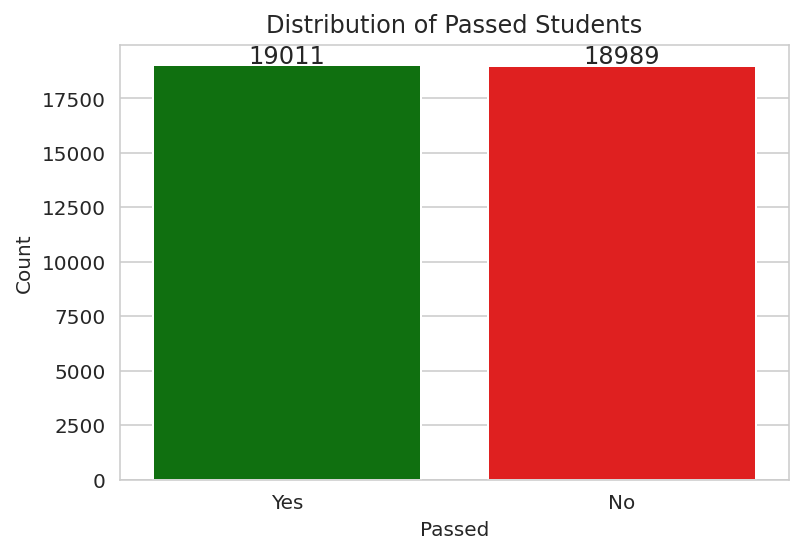

In [ ]:
passed_col = "Passed"

# Count the occurrences
passed_counts = data[passed_col].value_counts().reset_index()
passed_counts.columns = ["Passed", "Count"]

# Set style
sns.set_style("whitegrid")

# Create the bar plot
plt.figure(figsize=(6, 4))
sns.barplot(x="Passed", y="Count", hue="Passed", data=passed_counts,
            palette={"No": "red", "Yes": "green"}, legend=False)

# Add labels and title
plt.xlabel("Passed")
plt.ylabel("Count")
plt.title("Distribution of Passed Students")

# Show values on bars
for i, count in enumerate(passed_counts["Count"]):
    plt.text(i, count + 100, str(count), ha='center', fontsize=12)

# Show the plot
plt.show()

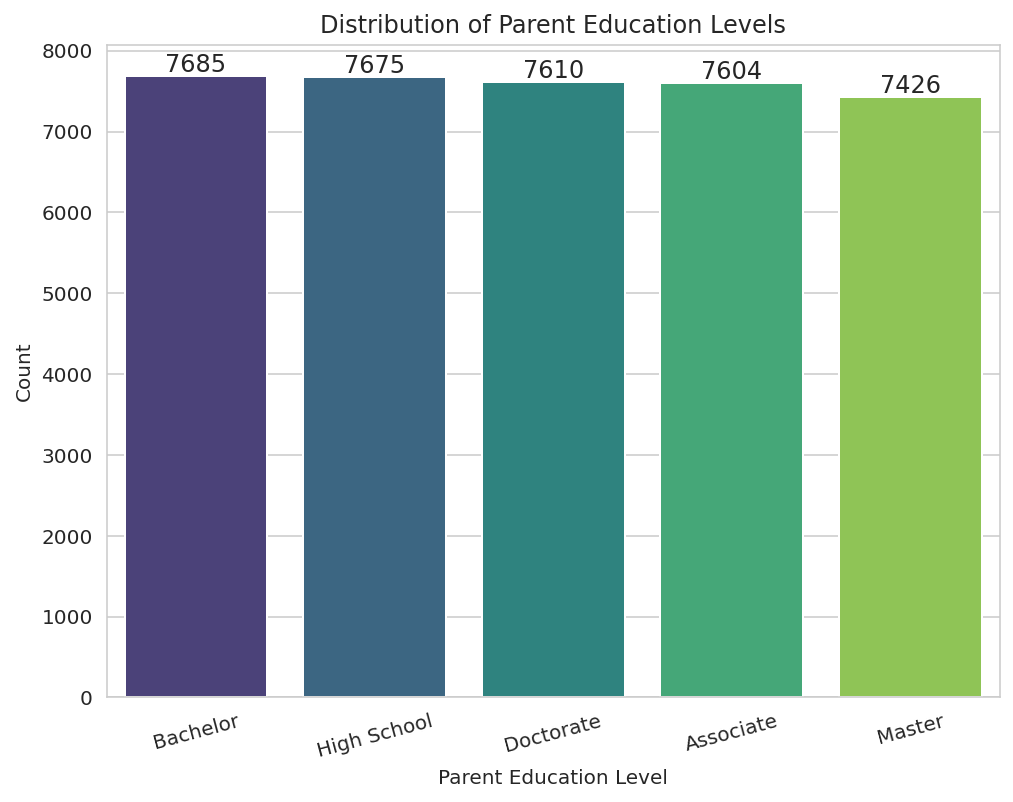

In [ ]:
# Count the occurrences of each education level
education_counts = data["Parent Education Level"].value_counts().reset_index()
education_counts.columns = ["Parent Education Level", "Count"]

# Create the bar chart
plt.figure(figsize=(8,6))
sns.barplot(data=education_counts, x="Parent Education Level", y="Count", hue="Parent Education Level", palette="viridis", legend=False)

# Add labels and title
plt.xlabel("Parent Education Level")
plt.ylabel("Count")
plt.title("Distribution of Parent Education Levels")

# Show values on bars
for i, count in enumerate(education_counts["Count"]):
    plt.text(i, count + 50, str(count), ha='center', fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=15)

# Show the plot
plt.show()

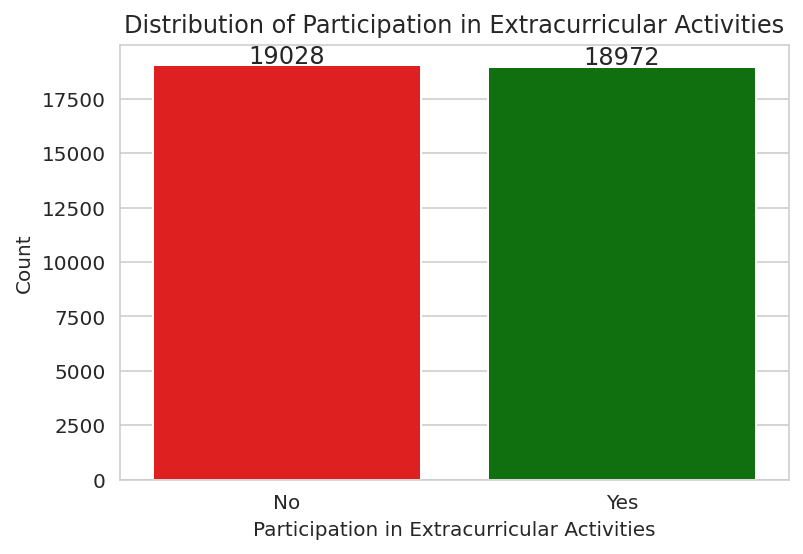

In [ ]:
# Create the bar plot
plt.figure(figsize=(6, 4))
sns.barplot(x="Extracurricular Activities", y="Count", hue="Extracurricular Activities",
            data=activity_counts, palette={"No": "red", "Yes": "green"}, legend=False)

# Add labels and title
plt.xlabel("Participation in Extracurricular Activities")
plt.ylabel("Count")
plt.title("Distribution of Participation in Extracurricular Activities")

# Show values on bars
for i, count in enumerate(activity_counts["Count"]):
    plt.text(i, count + 100, str(count), ha='center', fontsize=12)

# Show the plot
plt.show()

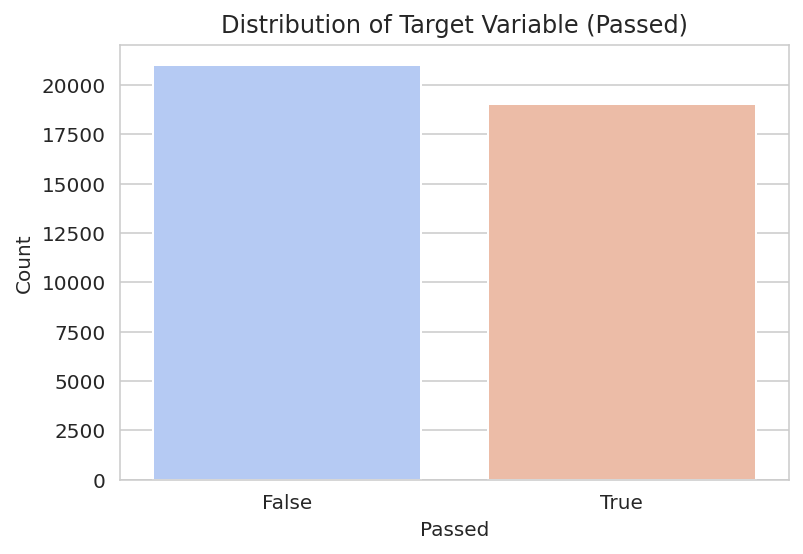

In [ ]:
# Distribution of the target variable
plt.figure(figsize=(6, 4))
sns.countplot(x=y, palette='coolwarm', hue=y, dodge=False, legend=False)
plt.title('Distribution of Target Variable (Passed)')
plt.xlabel('Passed')
plt.ylabel('Count')
plt.show()


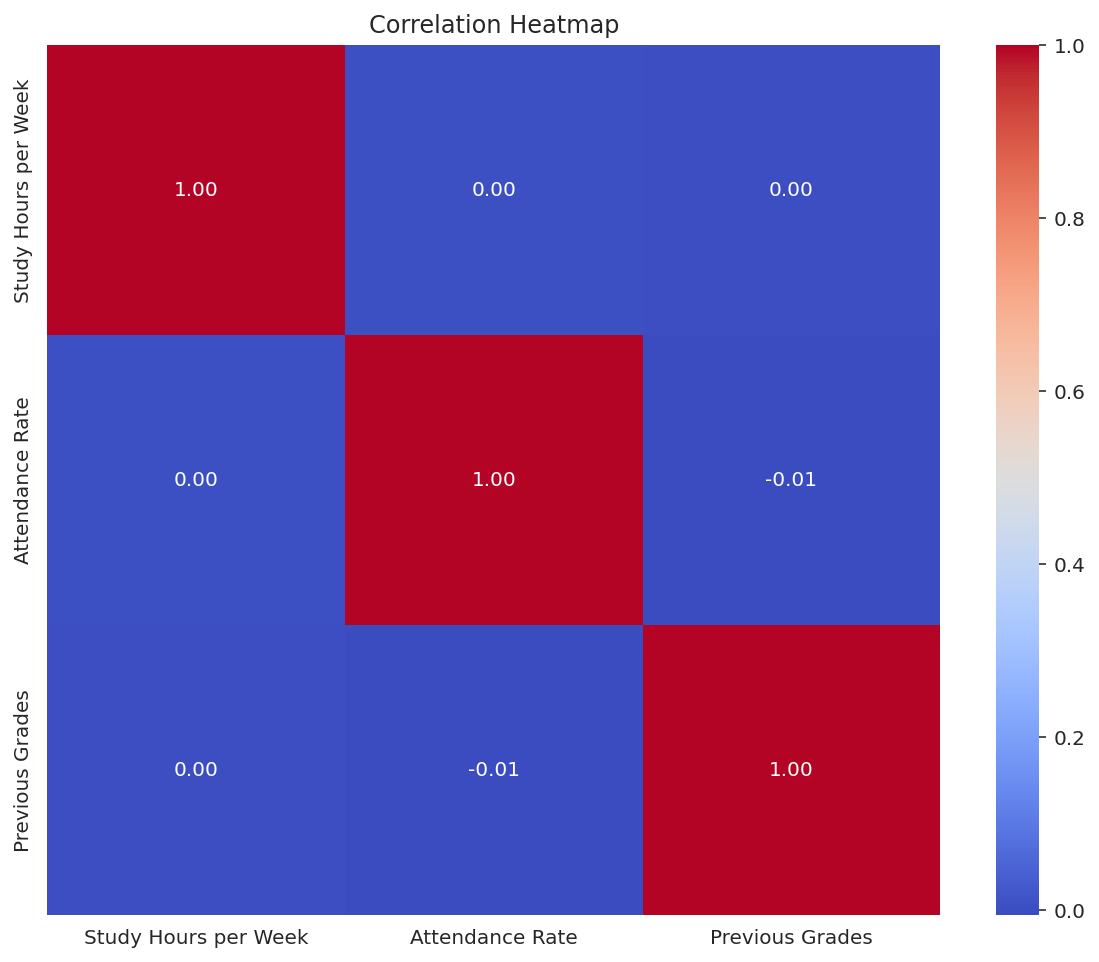

In [ ]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
numeric_data = data.select_dtypes(include=['float64', 'int64'])
corr_matrix = numeric_data.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Correlation Heatmap')
plt.show()

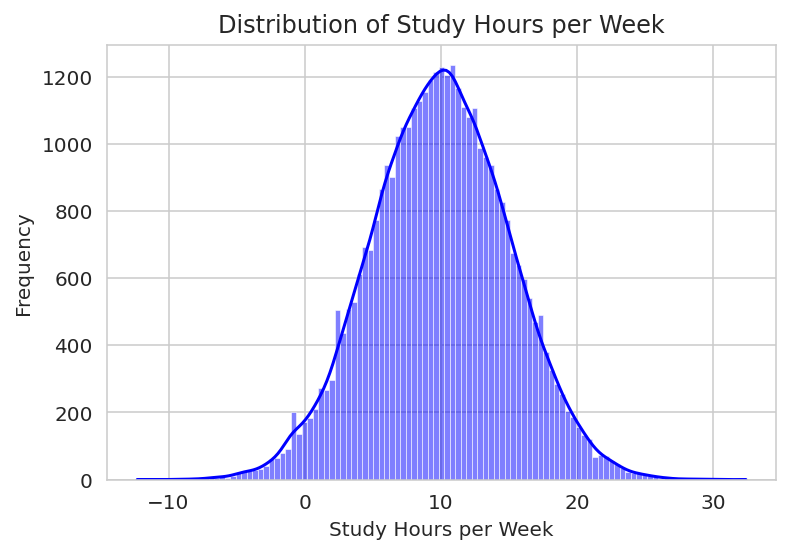

In [ ]:
# Distribution of Study Hours per Week
plt.figure(figsize=(6, 4))
sns.histplot(data['Study Hours per Week'], kde=True, color='blue')
plt.title('Distribution of Study Hours per Week')
plt.xlabel('Study Hours per Week')
plt.ylabel('Frequency')
plt.show()

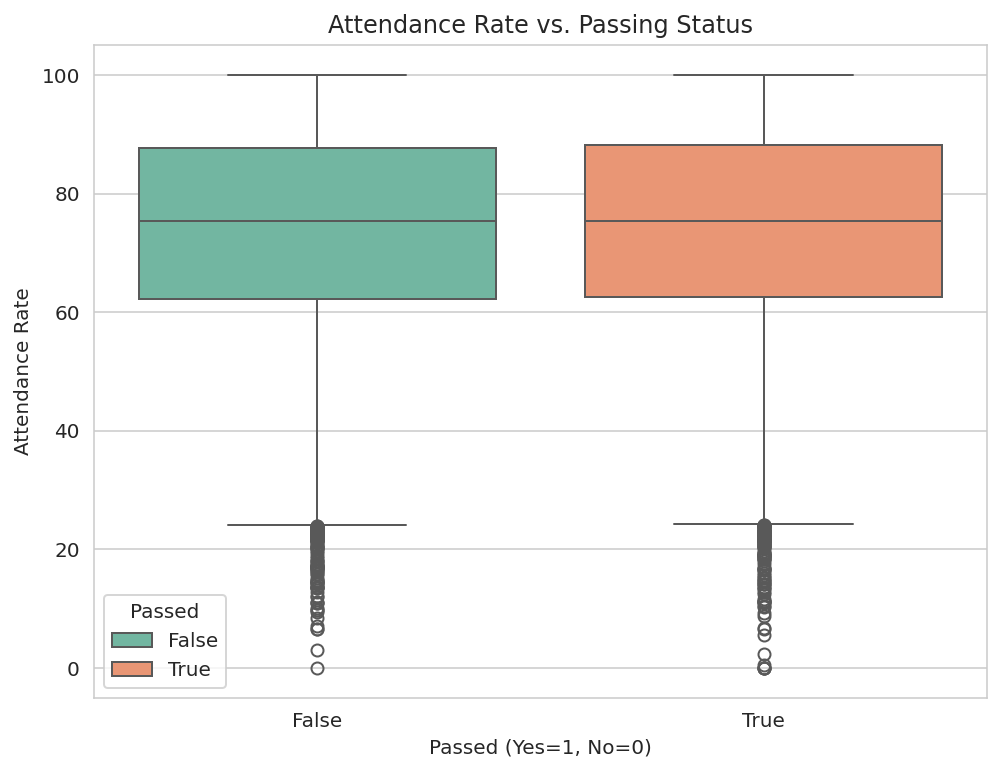

In [ ]:
# Attendance Rate vs. Passing Status
plt.figure(figsize=(8, 6))
sns.boxplot(x=y, y='Attendance Rate', data=pd.concat([X, y], axis=1), hue=y, palette='Set2', dodge=False)
plt.title('Attendance Rate vs. Passing Status')
plt.xlabel('Passed (Yes=1, No=0)')
plt.ylabel('Attendance Rate')
plt.legend(title='Passed')
plt.show()

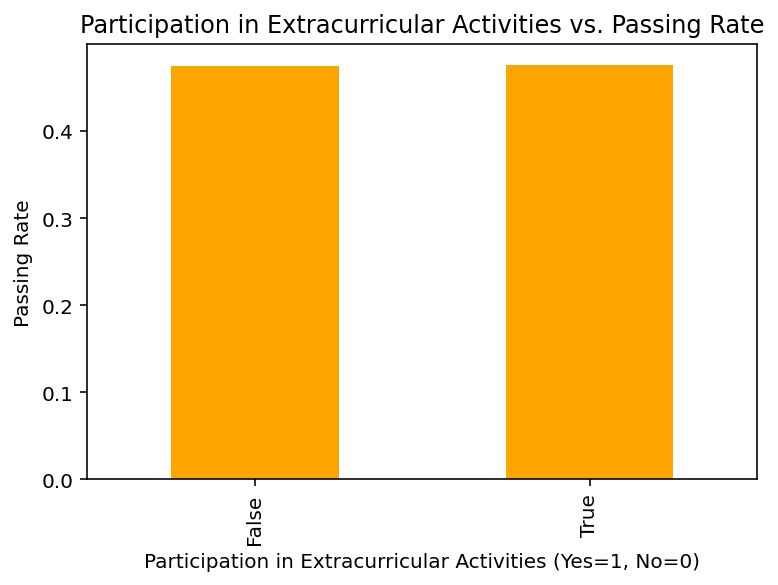

In [ ]:
# Participation in Extracurricular Activities vs. Passing Rate
participation_pass_rate = data.groupby('Participation in Extracurricular Activities_Yes')['Passed_Yes'].mean()
plt.figure(figsize=(6, 4))
participation_pass_rate.plot(kind='bar', color='orange')
plt.title('Participation in Extracurricular Activities vs. Passing Rate')
plt.xlabel('Participation in Extracurricular Activities (Yes=1, No=0)')
plt.ylabel('Passing Rate')
plt.show()

In [ ]:
# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

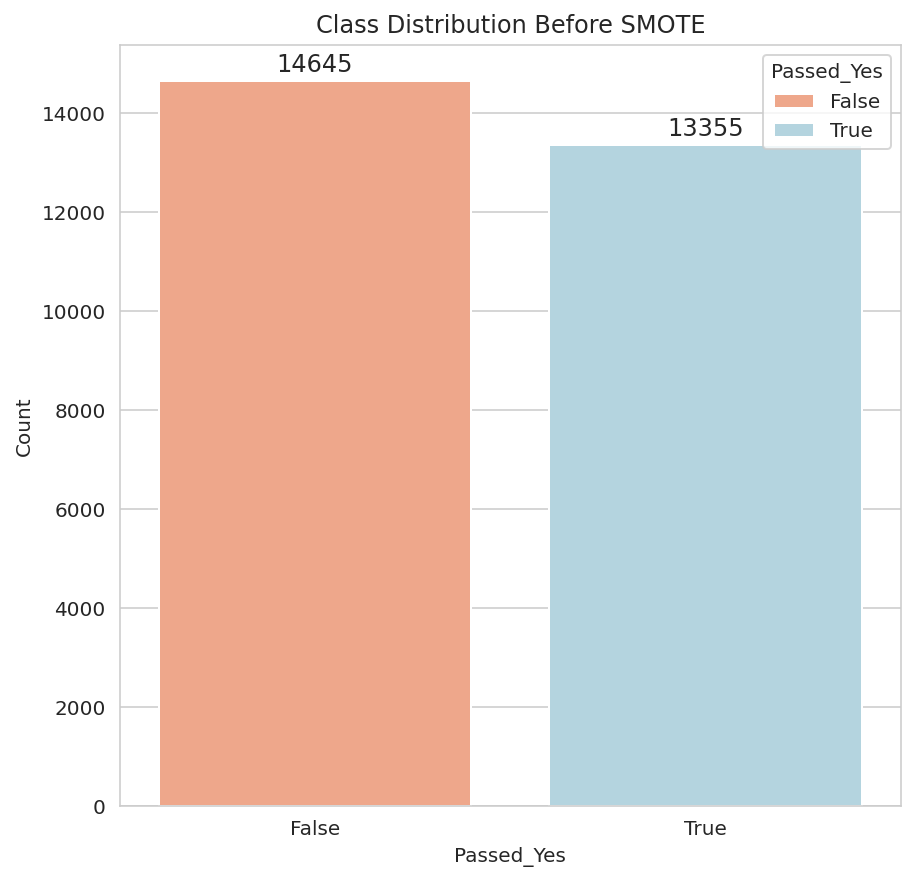

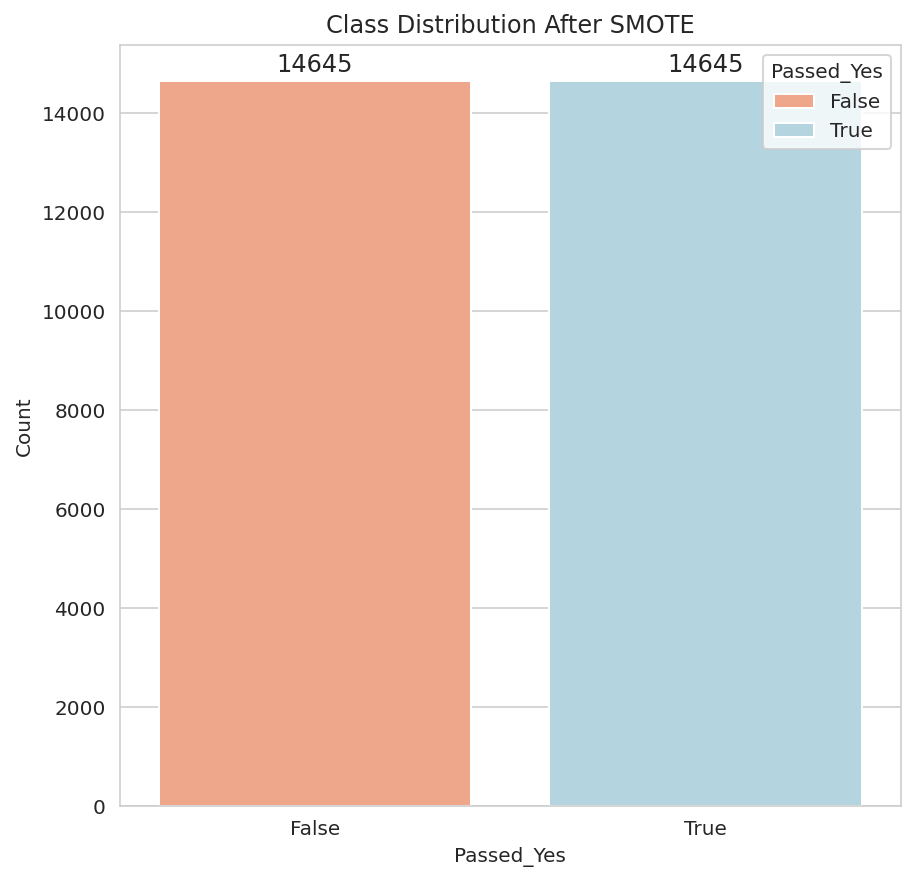

In [ ]:
# Before SMOTE: plot class distribution
class_counts_before = pd.Series(y_train).value_counts()
df_before = pd.DataFrame({'Passed_Yes': class_counts_before.index, 'Count': class_counts_before.values})

plt.figure(figsize=(7, 7))
ax_before = sns.barplot(x='Passed_Yes', y='Count', data=df_before, hue='Passed_Yes', palette=['lightsalmon', 'lightblue'])

# Add annotations for before SMOTE
for i, count in enumerate(class_counts_before):
    ax_before.text(i, count + 200, str(count), ha='center', fontsize=12)

plt.title('Class Distribution Before SMOTE')
plt.xlabel('Passed_Yes')
plt.ylabel('Count')
plt.show()

# After SMOTE: plot class distribution
class_counts_after = pd.Series(y_train_smote).value_counts()
df_after = pd.DataFrame({'Passed_Yes': class_counts_after.index, 'Count': class_counts_after.values})

plt.figure(figsize=(7, 7))
ax_after = sns.barplot(x='Passed_Yes', y='Count', data=df_after, hue='Passed_Yes', palette=['lightsalmon', 'lightblue'])

# Add annotations for after SMOTE
for i, count in enumerate(class_counts_after):
    ax_after.text(i, count + 200, str(count), ha='center', fontsize=12)

plt.title('Class Distribution After SMOTE')
plt.xlabel('Passed_Yes')
plt.ylabel('Count')
plt.show()


In [ ]:
# Grid search for KNN
param_grid = {'n_neighbors': list(range(1, 21))}
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, n_jobs=-1)
grid_search.fit(X_train_smote, y_train_smote)

best_k = grid_search.best_params_['n_neighbors']
print(f"Best k for KNN: {best_k}")

# Train the best KNN model
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train_smote, y_train_smote)


Best k for KNN: 13


KNeighborsClassifier(n_neighbors=13)

Training and Evaluating Random Forest...


Classification Report for Random Forest:
              precision    recall  f1-score   support

       False       1.00      0.90      0.95      6344
        True       0.90      1.00      0.95      5656

    accuracy                           0.95     12000
   macro avg       0.95      0.95      0.95     12000
weighted avg       0.95      0.95      0.95     12000



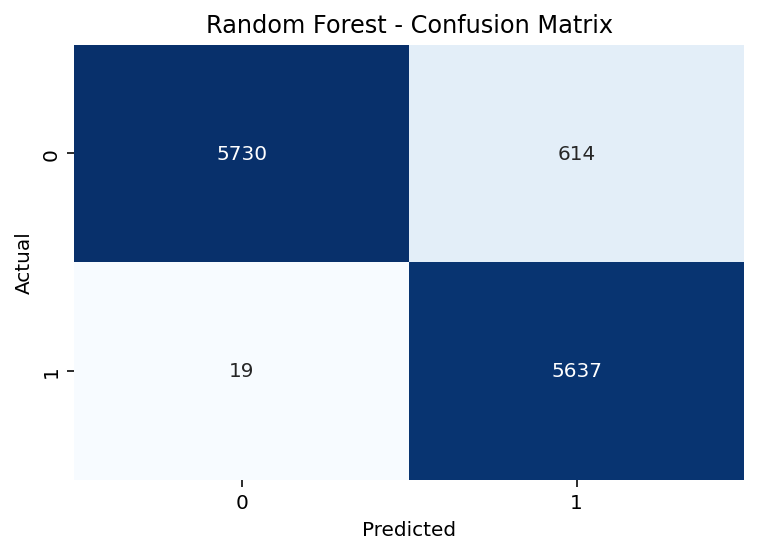

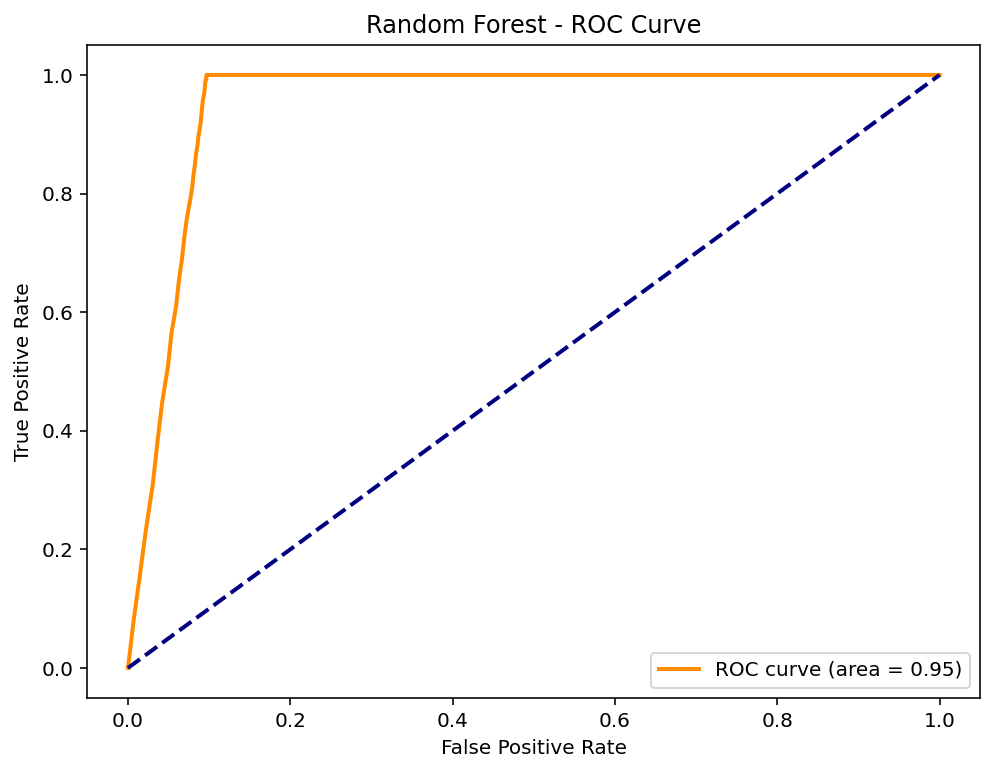

Training and Evaluating Logistic Regression...


Classification Report for Logistic Regression:
              precision    recall  f1-score   support

       False       1.00      0.90      0.95      6344
        True       0.90      1.00      0.95      5656

    accuracy                           0.95     12000
   macro avg       0.95      0.95      0.95     12000
weighted avg       0.95      0.95      0.95     12000



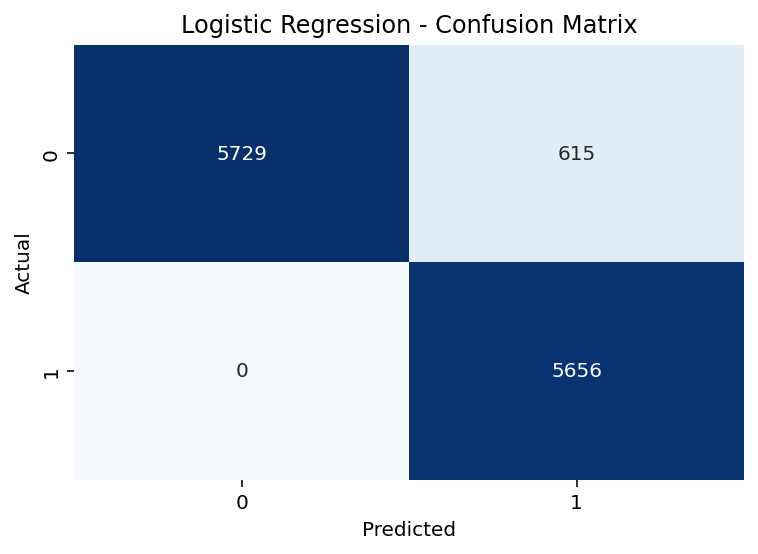

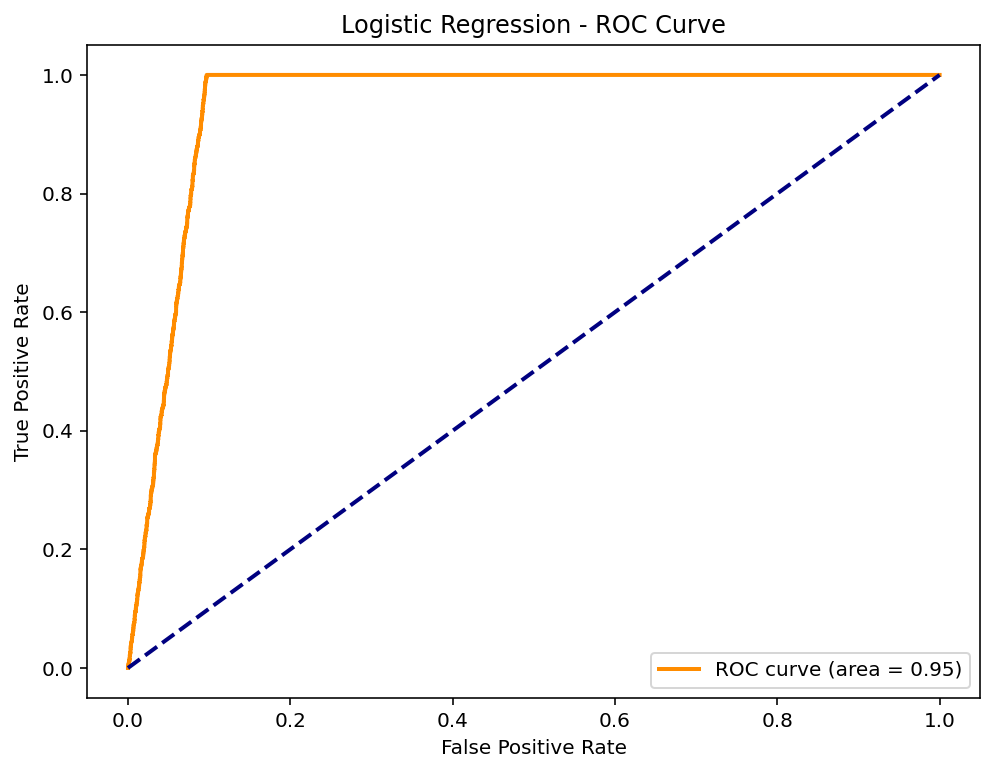

Training and Evaluating KNN...


Classification Report for KNN:
              precision    recall  f1-score   support

       False       0.98      0.90      0.94      6344
        True       0.90      0.98      0.94      5656

    accuracy                           0.94     12000
   macro avg       0.94      0.94      0.94     12000
weighted avg       0.94      0.94      0.94     12000



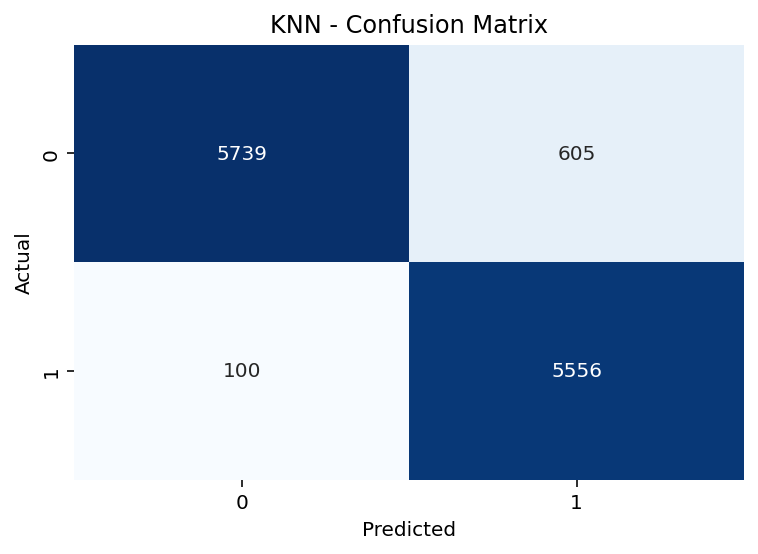

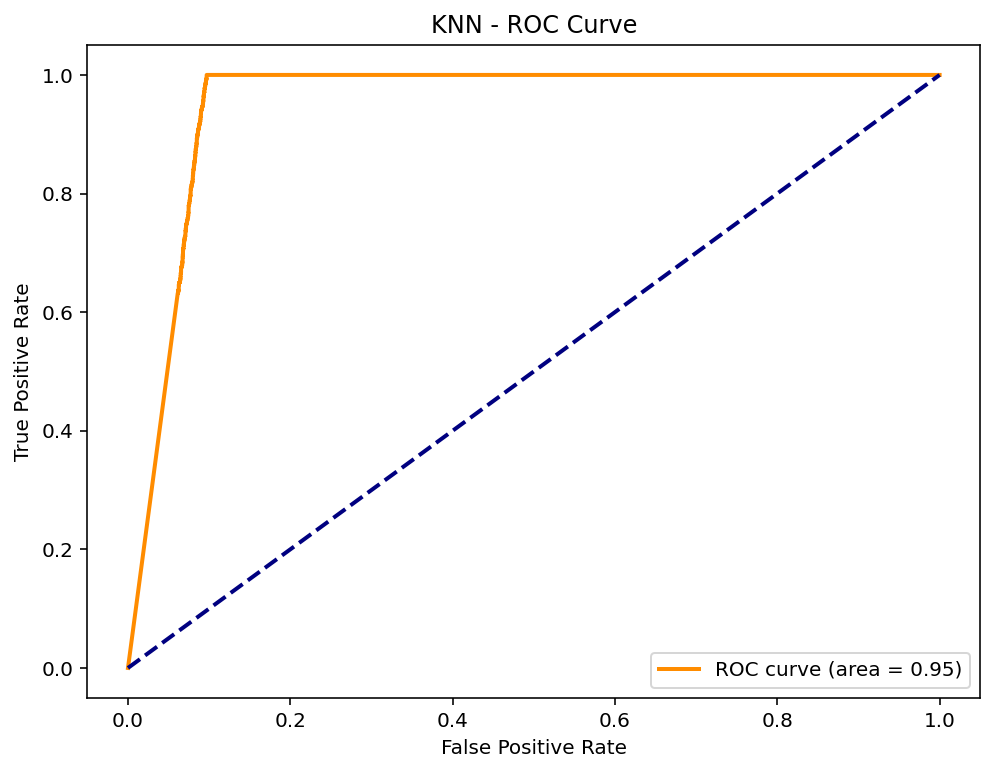

Training and Evaluating Gradient Boosting...


Classification Report for Gradient Boosting:
              precision    recall  f1-score   support

       False       1.00      0.90      0.95      6344
        True       0.90      1.00      0.95      5656

    accuracy                           0.95     12000
   macro avg       0.95      0.95      0.95     12000
weighted avg       0.95      0.95      0.95     12000



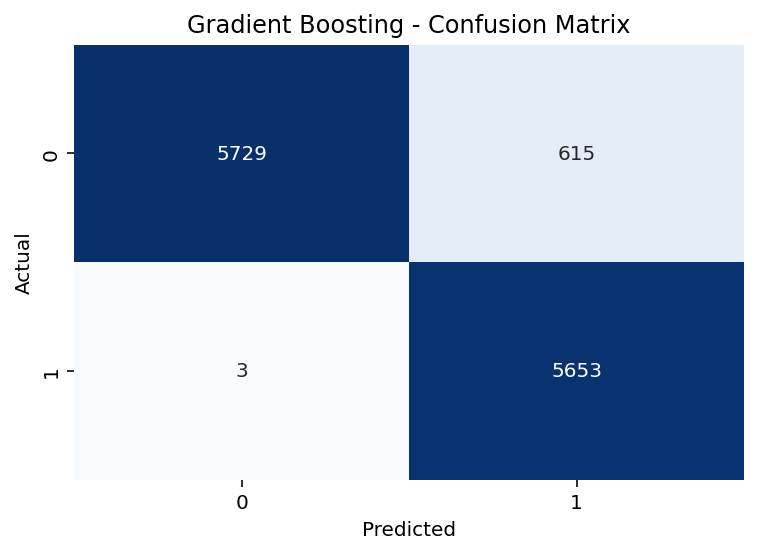

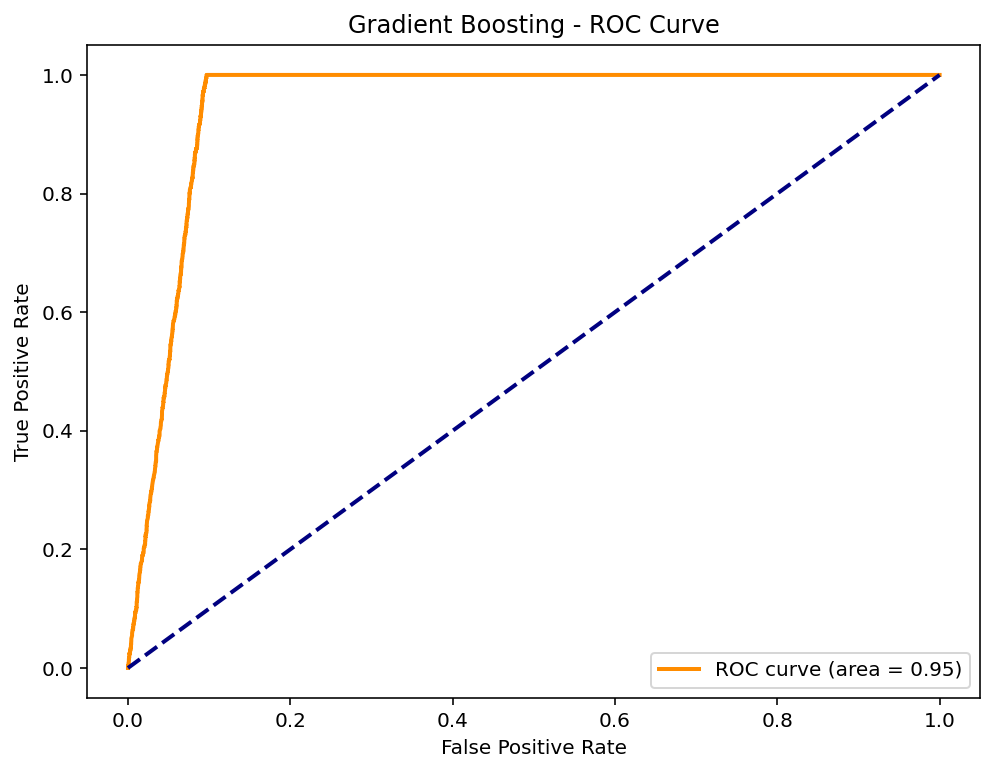

Training and Evaluating Naive Bayes...
Classification Report for Naive Bayes:
              precision    recall  f1-score   support

       False       1.00      0.90      0.95      6344
        True       0.90      1.00      0.95      5656

    accuracy                           0.95     12000
   macro avg       0.95      0.95      0.95     12000
weighted avg       0.95      0.95      0.95     12000



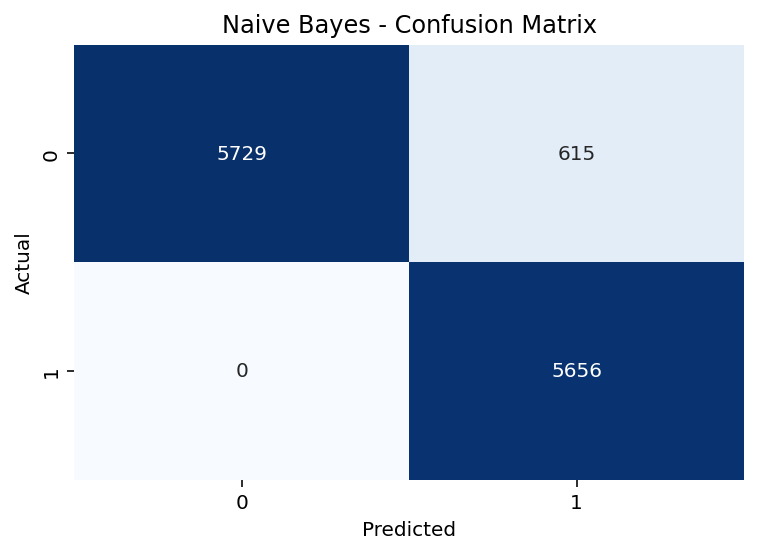

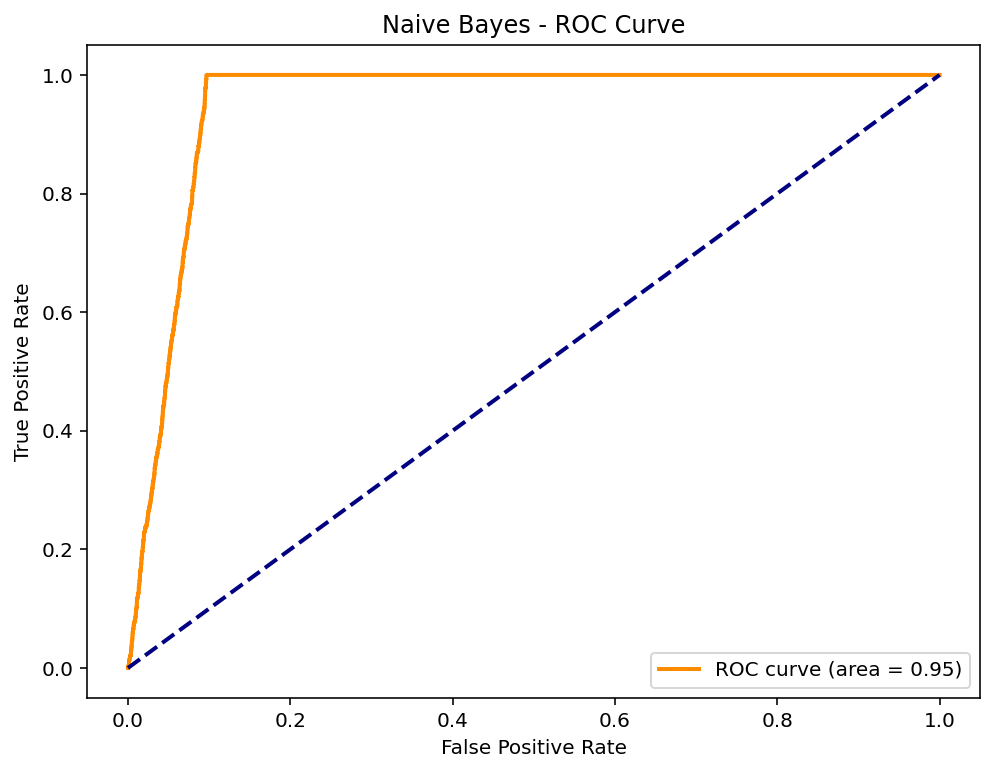

In [ ]:
models = {
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'KNN': KNeighborsClassifier(weights='distance'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Naive Bayes': GaussianNB()
}

# Train and evaluate models
for model_name, model in models.items():
    print(f"Training and Evaluating {model_name}...")
    model.fit(X_train_smote, y_train_smote)

    # Make predictions
    y_pred = model.predict(X_test)

    # Classification report
    print(f"Classification Report for {model_name}:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # ROC Curve
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.title(f'{model_name} - ROC Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.show()


In [ ]:
# Create individual model
rf = RandomForestClassifier(random_state=42)
log_reg = LogisticRegression(max_iter=1000, random_state=42)
nb = GaussianNB()

# Voting Classifier
voting_clf = VotingClassifier(estimators=[
    ('rf', rf),
    ('log_reg', log_reg),
    ('nb', nb)
], voting='hard')

# Train the voting classifier
voting_clf.fit(X_train_smote, y_train_smote)

# Make predictions
y_pred_voting = voting_clf.predict(X_test)

# Classification report
print("Classification Report for Voting Classifier:")
print(classification_report(y_test, y_pred_voting))


Classification Report for Voting Classifier:
              precision    recall  f1-score   support

       False       1.00      0.90      0.95      6344
        True       0.90      1.00      0.95      5656

    accuracy                           0.95     12000
   macro avg       0.95      0.95      0.95     12000
weighted avg       0.95      0.95      0.95     12000



# Conclusion

    The study explored the application of machine learning techniques to predict student performance using academic, demographic, and behavioral data. It demonstrated the potential of machine learning models to provide actionable insights, aiding educators in implementing early intervention strategies. By evaluating various classification algorithms, the study identified models capable of achieving high predictive accuracy, with notable findings summarized below. 

    The quality and completeness of data emerged as critical to the performance of predictive models. Preprocessing steps, such as addressing missing values and correcting inconsistencies, were essential to ensuring model reliability. Among the studied features, attendance rate, study hours per week, and previous grades were identified as significant predictors of student success, showing strong correlations with passing rates and contributing to the models' predictive accuracy. In terms of algorithms, Decision Tree, Random Forest, and Gradient Boosting methods demonstrated superior performance, effectively capturing complex relationships within the dataset. Additionally, the use of the Synthetic Minority Over-sampling Technique (SMOTE) successfully addressed class imbalance issues, enhancing model generalizability. Importantly, the developed models hold educational value by enabling educators to identify at-risk students early, facilitating timely and personalized interventions to improve academic outcomes.